<a href="https://colab.research.google.com/github/sowmyasameer4/ML-DL-Projects/blob/main/Fake_News_Detection/PROJECT(3)(fake_news_detection).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**

In the modern digital era, social media and online platforms have become major sources of news consumption. However, the rapid spread of misinformation and fake news poses serious risks to public opinion, decision-making, and societal stability. It is difficult for individuals and organizations to manually verify the authenticity of every news article due to the large volume of content generated daily.The dataset includes a target label where:


*   1 indicates fake news
*   0 indicates real news



The final system should be able to take a news article as input and accurately predict whether it is fake or real, helping to reduce the spread of misinformation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [ ]:
data = pd.read_csv("/content/fake_detection_data.csv")
data

,text,label
0,President-elect Donald Trump recently asked hi...,0
1,Right-wing morons everywhere are panicking abo...,0
2,Will this FINALLY be the straw that breaks the...,0
3,Nothing says respect for America and for your ...,0
4,Make America Conservative again. There really ...,0
...,...,...
44893,Sen. John McCain (R-AZ) was diagnosed with bra...,0
44894,NEW YORK (Reuters) - An artists’ collective to...,1
44895,BUENOS AIRES (Reuters) - Searchers for an Arge...,1
44896,MOSCOW (Reuters) - The decision by the United ...,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


In [ ]:
data.isnull().sum()

,0
text,0
label,0


## **Visualization**

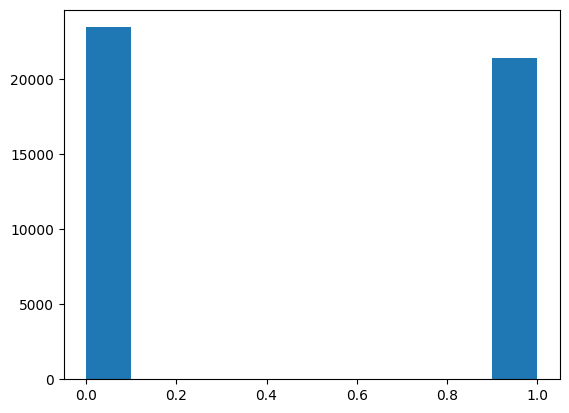

In [ ]:
plt.hist(data["label"])
plt.show()

## **NLP**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size = 0.25, random_state = 42
)

In [ ]:
pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

In [ ]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier', MultinomialNB())])

In [ ]:
preds = pipe.predict(x_test)

In [ ]:
print("Text Prediction:",preds)
print("Actual Labels:", y_test)
print("Accuracy:", accuracy_score(y_test, preds))

Text Prediction: [1 1 0 ... 0 1 1]
Actual Labels: 22216    1
27917    1
25007    0
1377     1
32476    0
        ..
15578    1
29394    0
3120     0
25388    1
14337    1
Name: label, Length: 11225, dtype: int64
Accuracy: 0.9540311804008909


In [ ]:
new_text = ["Nothing says respect for America and for your elected office like using an executive order to make it easier for people who entered our country illegally to break the law without fear of persecution Watch for the political stock of Mohamed Khairullah, the Syrian-born Mayor of Prospect Park, to rise in Democratic circles after he signed an executive order on Friday that declared the Passaic County borough of 5,865 a sanctuary for immigrants.Hailing from Aleppo, which has become synonymous with the worst violence of the long Syrian civil war and has thus created tens of thousands of refugees, Khairullah immigrated to the United States in 1991, was elected Councilman in 2001, and has been the Mayor since 2006.Khairullah directly refers to his own past in explaining why he signed the order: It is important to me as a person who came to the U.S as an immigrant, that we uphold our laws and values, he said Saturday, according to NJ.com. The U.S is the land of opportunity and dreams for many people all over the world. The heightened profile for Khairullah, a former teacher in the Paterson public schools who worked at Office Depot, represents growing political power for Muslims in New Jersey politics.Seven weeks ago, Passaic County elected its first Muslim Freeholder when Assad Akhter, a deputy chief of staff to U.S. Rep. Bill Pascrell and the son of Pakistani immigrants, took of the seat of Hector Lora. Lora resigned to become Mayor of Passaic. Observer NJ"]
new_pred = pipe.predict(new_text)
print("\nNew text:",new_text[0])
print("Predicted Label:", new_pred)


New text: Nothing says respect for America and for your elected office like using an executive order to make it easier for people who entered our country illegally to break the law without fear of persecution Watch for the political stock of Mohamed Khairullah, the Syrian-born Mayor of Prospect Park, to rise in Democratic circles after he signed an executive order on Friday that declared the Passaic County borough of 5,865 a sanctuary for immigrants.Hailing from Aleppo, which has become synonymous with the worst violence of the long Syrian civil war and has thus created tens of thousands of refugees, Khairullah immigrated to the United States in 1991, was elected Councilman in 2001, and has been the Mayor since 2006.Khairullah directly refers to his own past in explaining why he signed the order: It is important to me as a person who came to the U.S as an immigrant, that we uphold our laws and values, he said Saturday, according to NJ.com. The U.S is the land of opportunity and dreams

In [ ]:
import pickle
with open("Fake_News_Detection_model.pkl","wb")as file:
  pickle.dump(pipe,file)

# **CONCLUSION**


In this dataset, a fake news detection model was successfully developed using a **Pipeline** that integrates **CountVectorizer** and the **Multinomial Naive Bayes (MultinomialNB)** algorithm. The CountVectorizer converted the text data into numerical form, and the MultinomialNB classifier effectively learned patterns to distinguish between fake and real news. Using a pipeline simplified the workflow by combining preprocessing and model training into a single step. The trained model achieved reliable classification performance and was finally saved in **pickle format**, enabling easy reuse for future predictions without retraining the model.
